<a href="https://colab.research.google.com/github/hwasun-zip/kakaogames01/blob/main/kakaogames01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 라이브러리 설치
!pip install google-play-scraper -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 1.9 MB/s eta 0:00:00


In [2]:
# 앱이 스토어에 남아있는지 먼저 확인
from google_play_scraper import app, reviews, Sort

APP_ID = "com.kakaogames.eversoul"   # 에버소울 구글플레이 패키지 ID

try:
    info = app(APP_ID, lang="ko", country="kr")
    print("✅ 앱 페이지 존재")
    print("  제목 :", info["title"])
    print("  평점 :", info.get("score"))
    print("  리뷰수:", info.get("reviews"))
    print("  설치 :", info.get("installs"))
except Exception as e:
    print("❌ 앱을 못 찾음 → 스토어에서 내려갔을 가능성. CELL 6(플랜 B) 사용")
    print("   에러:", e)

❌ 앱을 못 찾음 → 스토어에서 내려갔을 가능성. CELL 6(플랜 B) 사용
   에러: App not found(404).


In [3]:
# 리뷰 대량 수집
# count 를 늘리면 더 많이 긁힘. 우선 2000개로 테스트
import pandas as pd

all_reviews, _ = reviews(
    APP_ID,
    lang="ko",
    country="kr",
    sort=Sort.NEWEST,     # 최신순 (종료 직전 여론까지 확보)
    count=2000,           # 잘 되면 5000~10000 으로 상향
)

df = pd.DataFrame(all_reviews)
print("수집된 리뷰 수:", len(df))
df = df[["userName", "score", "at", "content", "thumbsUpCount"]]
df = df.rename(columns={"at": "date", "content": "review", "thumbsUpCount": "likes"})
df["date"] = pd.to_datetime(df["date"])
df.head(10)

수집된 리뷰 수: 2000


,userName,score,date,review,likes
0,차민혁,5,2026-07-18 14:27:44,다시 꼭 만나자,0
1,Knight,5,2026-07-17 16:57:04,가장 힘들 때 곁에 있어준 유일한 존재가 에버소울이었습니다. 저를 구원해주셔서 감사...,0
2,넌누구냐,5,2026-07-12 08:34:03,"정말 열심히 했고, 재밌게 즐겼으며, 애정도 깊었던 게임입니다. 감사했습니다.",0
3,정은수,5,2026-07-12 00:38:30,❤️,0
4,권주호,5,2026-07-11 08:46:47,재밌게 플레이 했는데 이렇게 서비스 종료을 하다니 아쉽습니다 4주년이나 5주년 기달...,0
5,Wasteland,5,2026-07-07 12:16:14,작별인사,0
6,MASTERPIECE,5,2026-07-06 23:42:47,잘가 에버소울 나름 1주년 때 복귀해서 꾸준히 열심히 했었다.. 추억 속에 남겨둘게..,0
7,HeroLD준현,5,2026-07-03 01:38:53,섭종.. ㅠㅠ 서비스 이어가주셔서 감사했습니다. 에버소울 세계의 끝을 보지 못해 아...,0
8,SH Y,1,2026-07-02 19:48:53,이젠 정말 갔구만,0
9,허미옥,5,2026-07-02 03:20:28,제 인생작인게임입니다,1


In [4]:
# 수집 데이터 저장 (CSV) + 간단 요약
df.to_csv("eversoul_reviews.csv", index=False, encoding="utf-8-sig")
print("💾 저장 완료: eversoul_reviews.csv")
print("기간:", df["date"].min(), "~", df["date"].max())
print("\n별점 분포:")
print(df["score"].value_counts().sort_index())

💾 저장 완료: eversoul_reviews.csv
기간: 2023-01-22 03:49:15 ~ 2026-07-18 14:27:44

별점 분포:
score
1     298
2      89
3     146
4     219
5    1248
Name: count, dtype: int64


In [5]:
!apt-get install -y fonts-nanum
!fc-cache -fv

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 3 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 1s (17.6 MB/s)
Selecting previously unselected package fonts-nanum.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/s

In [6]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
fm.fontManager.addfont(path)                          # 폰트 등록
plt.rcParams["font.family"] = fm.FontProperties(fname=path).get_name()  # 실제 이름으로 지정
plt.rcParams["axes.unicode_minus"] = False
print("폰트:", plt.rcParams["font.family"])

폰트: ['NanumGothic']


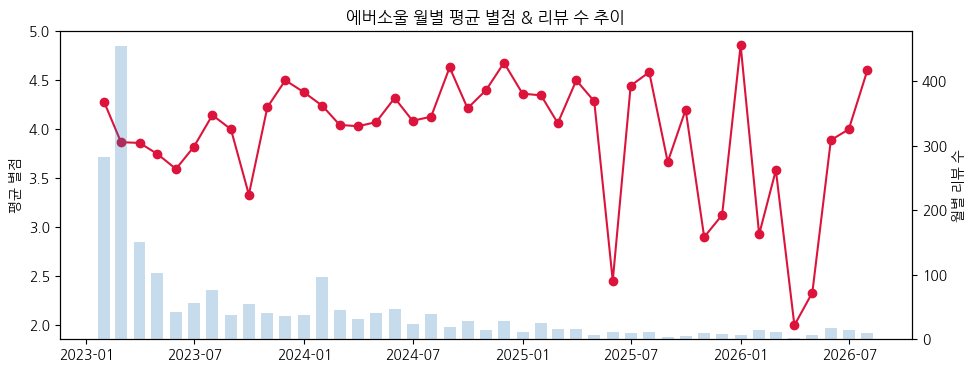

In [7]:
# 월별 평균 별점 추이 (이탈 시점 힌트)
import matplotlib.pyplot as plt

monthly = df.set_index("date").resample("ME").agg(
    avg_score=("score", "mean"),
    review_count=("review", "count"),
)
fig, ax1 = plt.subplots(figsize=(11, 4))
ax1.plot(monthly.index, monthly["avg_score"], "o-", color="crimson", label="평균 별점")
ax1.set_ylabel("평균 별점")
ax2 = ax1.twinx()
ax2.bar(monthly.index, monthly["review_count"], width=20, alpha=0.25, label="리뷰 수")
ax2.set_ylabel("월별 리뷰 수")
plt.title("에버소울 월별 평균 별점 & 리뷰 수 추이")
plt.savefig("eversoul_score_trend.png", dpi=150, bbox_inches="tight")
plt.show()

In [8]:
# 데이터 로드 + 감성 라벨 부여
# 4~5★ = 긍정(USP 후보) / 1~2★ = 부정(Pain Point 후보) / 3★ = 중립(제외)

import pandas as pd

df = pd.read_csv("eversoul_reviews.csv")
df["date"] = pd.to_datetime(df["date"])

def label(s):
    if s >= 4: return "긍정"
    if s <= 2: return "부정"
    return "중립"

df["sentiment"] = df["score"].apply(label)
print(df["sentiment"].value_counts())

pos = df[df["sentiment"] == "긍정"]
neg = df[df["sentiment"] == "부정"]
print(f"\n긍정 리뷰 {len(pos)}개 / 부정 리뷰 {len(neg)}개")

sentiment
긍정    1467
부정     387
중립     146
Name: count, dtype: int64

긍정 리뷰 1467개 / 부정 리뷰 387개


In [9]:
# 한국어 형태소 분석기 설치 + 키워드 추출 함수
!pip install konlpy -q

from konlpy.tag import Okt
from collections import Counter
import re

okt = Okt()

# 분석에 방해되는 불용어
STOPWORDS = set("""
게임 진짜 그냥 정말 너무 이거 저거 근데 그리고 하지만 그래서 이건 저건 요즘 지금
에버 소울 에버소울 요 좀 걍 더 것 수 게 거 저 이 그 때 개 명 안 못 왜 다 또 는 은
 없다 있다 같다 많다 좋다 아니다 안되다 그렇다 이다 정도 유저 생각 린다 하나 이렇다 그렇다""".split())

def extract_keywords(text_series, pos_filter=("Noun", "Adjective"), min_len=2):
    words = []
    for t in text_series.dropna():
        t = re.sub(r"[^가-힣a-zA-Z ]", " ", str(t))     # 한글/영문만
        for word, tag in okt.pos(t, stem=True):          # stem=True: 어간 정규화
            if tag in pos_filter and len(word) >= min_len and word not in STOPWORDS:
                words.append(word)
    return Counter(words)

print("키워드 추출 준비 완료")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 86.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 438.5/438.5 kB 27.0 MB/s eta 0:00:00
키워드 추출 준비 완료


▼ 유저 불만(Pain Point) TOP 25
  버그       44
  스토리      40
  뽑기       37
  캐릭터      37
  화면       35
  업데이트     33
  접속       27
  계속       27
  방치       27
  시간       26
  로딩       25
  계정       24
  캐릭       23
  과금       23
  확률       22
  영지       22
  운영       21
  오류       21
  최적화      20
  진행       18
  정령       18
  재미       17
  시작       17
  어떻다      17
  삭제       17


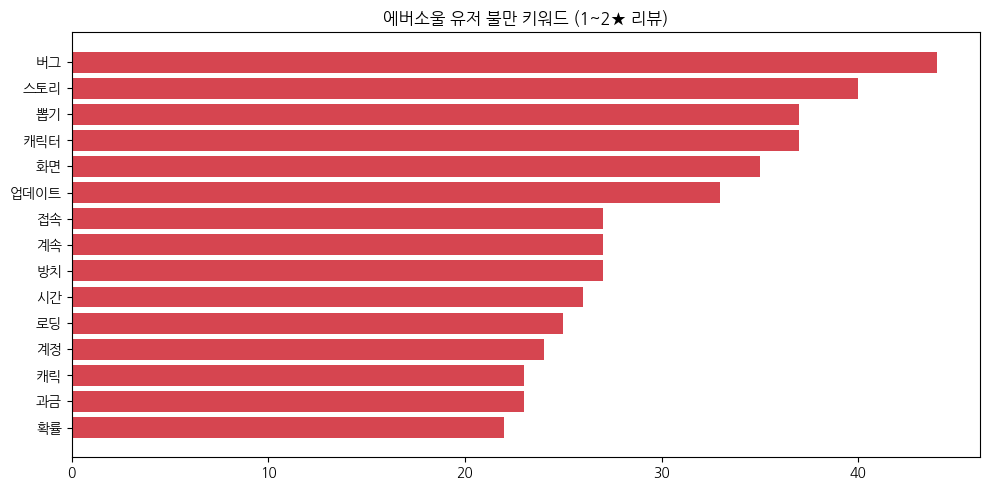

In [10]:
# PainPoint: 부정 리뷰(1~2★)에서 자주 나오는 키워드
pain = extract_keywords(neg["review"])
print("▼ 유저 불만(Pain Point) TOP 25")
for w, c in pain.most_common(25):
    print(f"  {w:8s} {c}")

top_pain = pain.most_common(15)
plt.figure(figsize=(10, 5))
plt.barh([w for w, _ in top_pain][::-1], [c for _, c in top_pain][::-1], color="#d64550")
plt.title("에버소울 유저 불만 키워드 (1~2★ 리뷰)")
plt.savefig("eversoul_pain.png", dpi=150, bbox_inches="tight")
plt.tight_layout(); plt.show()

▼ 유저 환호(USP) TOP 25
  재밌다      224
  캐릭터      140
  스토리      140
  재미있다     133
  과금       92
  재미       78
  컨텐츠      62
  정령       57
  이벤트      57
  플레이      53
  이쁘다      50
  뽑기       43
  업데이트     43
  전투       42
  괜찮다      40
  시간       36
  아쉽다      35
  시작       34
  영지       34
  캐릭       33
  계속       32
  처음       31
  보상       30
  방치       29
  꾸준하다     28


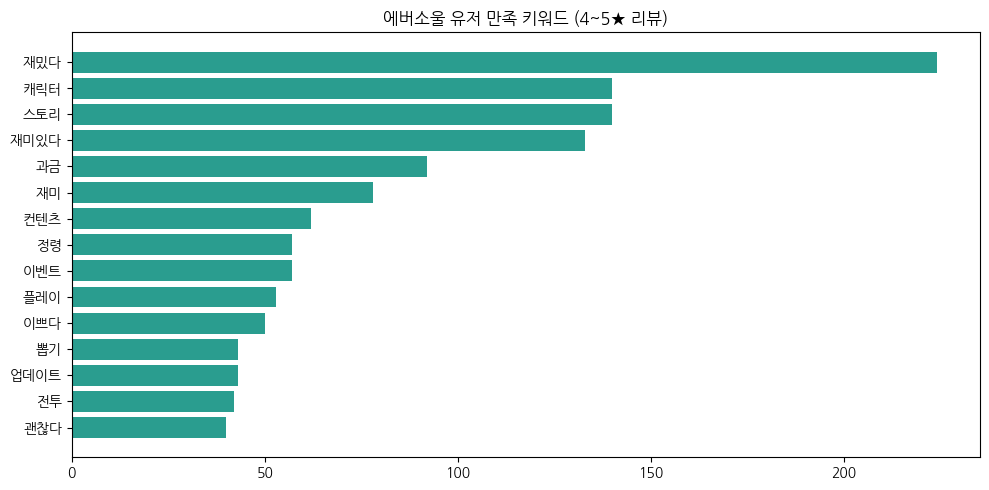

In [11]:
# USP: 긍정 리뷰(4~5★)에서 자주 나오는 키워드
usp = extract_keywords(pos["review"])
print("▼ 유저 환호(USP) TOP 25")
for w, c in usp.most_common(25):
    print(f"  {w:8s} {c}")

top_usp = usp.most_common(15)
plt.figure(figsize=(10, 5))
plt.barh([w for w, _ in top_usp][::-1], [c for _, c in top_usp][::-1], color="#2a9d8f")
plt.title("에버소울 유저 만족 키워드 (4~5★ 리뷰)")
plt.savefig("eversoul_usp.png", dpi=150, bbox_inches="tight")
plt.tight_layout(); plt.show()

In [12]:
def sample_reviews(keyword, sentiment, n=5):
    sub = df[(df["sentiment"] == sentiment) & (df["review"].fillna("").str.contains(keyword))]
    print(f"\n=== '{keyword}' ({sentiment}) {len(sub)}건 중 예시 ===")
    for r in sub.sort_values("likes", ascending=False)["review"].head(n):
        print("·", str(r)[:120])

sample_reviews("버그", "부정")
sample_reviews("방치", "부정")
sample_reviews("과금", "부정")
sample_reviews("과금", "긍정")
sample_reviews("스토리", "긍정")


=== '버그' (부정) 31건 중 예시 ===
· 5점이었으나 버그 방치로인해 수정함 1.영지 알바버그가 유저마다 랜덤으로 걸림 2.문제점을 파악하고 있음에도 방관하는 태도 3.결국 오픈 한달차가 돼서야 2월 9일쯤 고친다는데, 시스템상 유저마다 다르게 손해가 누적
· 게임 오픈일부터 4월 첫주까지는 버그가 많지만 그럭저럭 재밌게 잘했다... 그런데 어떤 특정조건에서의 버그가 발생해서 게임내 특정콘텐츠에 입장만하면 게임이 강제종료되면서 팅기는 현상이 발생했다. 처음 버그 발생날 1
· 새 기능에 버그 수정 및 서비스 안정화 라고 게시 해두셨는데 제작진 및 운영진 여러분, 여러분이 하실 일 안 끝났습니다. 유물 소환 버그 났습니다. 위시리스트 설정해두고 유물 소환 하려하면 네트워크 환경이 원활치 않
· 이 게임은 고인물 게임이라 늦게 시작한 유저가 절대로 기존유저 못 따라가는 게임이고... 최적화는 쓰레기고 당연히 버그도 많습니다. 아레나는 운빨요소 심하고 길레는 당연히 상위권 길드에 신규유저가 못 들어갑니다. 그
· 정령휴식 튜토리얼 팝업이 제거가 안되네요 뭔짓을해도 "빈슬롯이 없습니다 영지 레벨업을 통해 슬롯을 확장할 수 있습니다" 문구뜨면서 휴식란에 정령이 꽉차면 아무것도 못하고 게임꺼야됩니다. 영지레벨업해서 슬롯확장하고 정

=== '방치' (부정) 19건 중 예시 ===
· 5점이었으나 버그 방치로인해 수정함 1.영지 알바버그가 유저마다 랜덤으로 걸림 2.문제점을 파악하고 있음에도 방관하는 태도 3.결국 오픈 한달차가 돼서야 2월 9일쯤 고친다는데, 시스템상 유저마다 다르게 손해가 누적
· 게임 오픈일부터 4월 첫주까지는 버그가 많지만 그럭저럭 재밌게 잘했다... 그런데 어떤 특정조건에서의 버그가 발생해서 게임내 특정콘텐츠에 입장만하면 게임이 강제종료되면서 팅기는 현상이 발생했다. 처음 버그 발생날 1
· 밸런스 망겜임 아레나 시간은 짧아가지고 방어덱만 하면 이기고 전투력은 믿을게 못 되고 어떻게 된게 아레나에서 전투력 2만 이상 낮은 애한테 지고 

In [13]:
#  블루 아카이브 수집 및 분석 + 에버소울 비교
#  블루 아카이브 리뷰 수집

from google_play_scraper import reviews, Sort
import pandas as pd

APP_ID = "com.nexon.bluearchive"   # 블루 아카이브 (한국)

ba_raw, _ = reviews(APP_ID, lang="ko", country="kr", sort=Sort.NEWEST, count=2000)
ba = pd.DataFrame(ba_raw)[["userName", "score", "at", "content", "thumbsUpCount"]]
ba = ba.rename(columns={"at": "date", "content": "review", "thumbsUpCount": "likes"})
ba["date"] = pd.to_datetime(ba["date"])
ba.to_csv("bluearchive_reviews.csv", index=False, encoding="utf-8-sig")

print("블아 수집:", len(ba), "개")
print("기간:", ba["date"].min(), "~", ba["date"].max())
print("\n별점 분포:")
print(ba["score"].value_counts().sort_index())

블아 수집: 2000 개
기간: 2023-08-03 19:00:56 ~ 2026-07-29 03:14:00

별점 분포:
score
1     310
2      65
3     102
4     128
5    1395
Name: count, dtype: int64


In [14]:
# 감성 라벨 + 긍/부정 분리 (에버소울과 동일 기준)
def label(s):
    if s >= 4: return "긍정"
    if s <= 2: return "부정"
    return "중립"

ba["sentiment"] = ba["score"].apply(label)
ba_pos = ba[ba["sentiment"] == "긍정"]
ba_neg = ba[ba["sentiment"] == "부정"]
print(ba["sentiment"].value_counts())
print(f"\n긍정 {len(ba_pos)} / 부정 {len(ba_neg)}")

sentiment
긍정    1523
부정     375
중립     102
Name: count, dtype: int64

긍정 1523 / 부정 375


In [15]:
# 키워드 추출 (extract_keywords 재사용)
ba_pain = extract_keywords(ba_neg["review"])
ba_usp  = extract_keywords(ba_pos["review"])

print("▼ 블아 Pain Point TOP 20")
for w, c in ba_pain.most_common(20):
    print(f"  {w:8s} {c}")

print("\n▼ 블아 USP TOP 20")
for w, c in ba_usp.most_common(20):
    print(f"  {w:8s} {c}")

▼ 블아 Pain Point TOP 20
  스토리      82
  캐릭터      70
  확률       58
  픽업       43
  천장       31
  캐릭       27
  뽑기       26
  넥슨       25
  계정       24
  전투       23
  학생       23
  컨텐츠      23
  이벤트      22
  과금       19
  플레이      19
  사람       19
  재미       18
  더빙       18
  총력전      18
  가챠       18

▼ 블아 USP TOP 20
  스토리      410
  캐릭터      228
  재밌다      187
  블루       139
  아카이브     136
  용하다      123
  학생       105
  최고       86
  재미있다     77
  사랑       75
  인생       65
  루쨩아루쨔아루  55
  이벤트      53
  컨텐츠      50
  귀엽다      50
  시작       49
  매력       49
  플레이      49
  아쉽다      48
  메인       44


In [16]:
# 맥락 확인용 실제 리뷰 (* '운영/소통/스토리')
def ba_sample(keyword, sentiment, n=5):
    sub = ba[(ba["sentiment"] == sentiment) & (ba["review"].fillna("").str.contains(keyword))]
    print(f"\n=== '{keyword}' ({sentiment}) {len(sub)}건 중 예시 ===")
    for r in sub.sort_values("likes", ascending=False)["review"].head(n):
        print("·", str(r)[:120])

ba_sample("운영", "긍정")
ba_sample("스토리", "긍정")
ba_sample("소통", "긍정")


=== '운영' (긍정) 19건 중 예시 ===
· 나이 많이 먹진 않았음에도 불구하고 그저 귀여운 딸래미들 보는 느낌이에요~ 학생들 하나하나가 개성 넘치고, 일러스트와 3D 모델 모두 퀄리티가 높은 것 같습니다. 특유의 그림체도 마음에 들고, 3D 모델의 모션은 귀
· 매력적인 캐릭터,좋은 스토리 등 할게 많은 게임입니다. 초반에는 빈약한 게임성 등으로 많은 질타를 받았지만 오히려 지금 많은 즐길거리등 개발진들의 노력과 애정이 보일정도로 좋습니다. 가챠또한 많은 피드백등을 거듭하여
· 장점은 재화 수급이 막 어렵지 않고 서비스와 소통이 은근 잘됩니다. 단점은 나중에 스토리 다 보면 은근 할게 없다. 종도지만 이벤트 스토리가 잘나와서 괜찮습니다. 이대로 만 운영 해주시면 좋겠네요. 좋은 게임 감사합
· 솔직히 피파보단 블루 아카이브가 운영 더 잘하는듯ㅋㅋ
· 기사나 마법사가 나오는 중세판타지풍 게임에 익숙해서 그랬던건지 오랫동안 끄적거리지만하고 재미를 못붙였었는데 오히려 더 재밌는거 같아요 최근에 보안 문제 뉴스를 보았는데 온라인게임에 보안을 비롯한 안정적인 운영보다 중

=== '스토리' (긍정) 292건 중 예시 ===
· 블루아카이브를 시작한지 1년정도 되어가고 있네요... 정말 재미있게 하며 애정을 가지게 된 게임이 되었습니다 ㅎㅎ 그간 게임을 하면서 느껴본 것을 끄적써봅니다. 일단 장점으로는 캐릭터 하나하나가 매력이 넘칩니다. 캐
· 저는 예전계정을 포함하면 출시때부터 시작하였던 선생님 입니다. 초기 2021년에는 당시 기준 게임이 타사게임보다 꾀나 괜찮은 성능을 가지고 있었으나. 지금은 4년이란 시간에 저희 선생님들은 4주년의 약간 실망으로 인
· 하도 유명하길래 한번 해보고 솔직한 리뷰 남길게요. 1. 캐릭터 일러스트는 늘 보던 느낌이라 큰 감흥 없었는데 SD 캐릭터들 모션이 너무 귀여움. 성우도 알맞게 잘 쓴 느낌이라 이질감 없어 좋음. 2.메인스토리, 캐
· 솔직히 말해서 요즘 공략도 많이 올라와서 골드컷도 이제 인세인을깨야 될정도로 수준이 

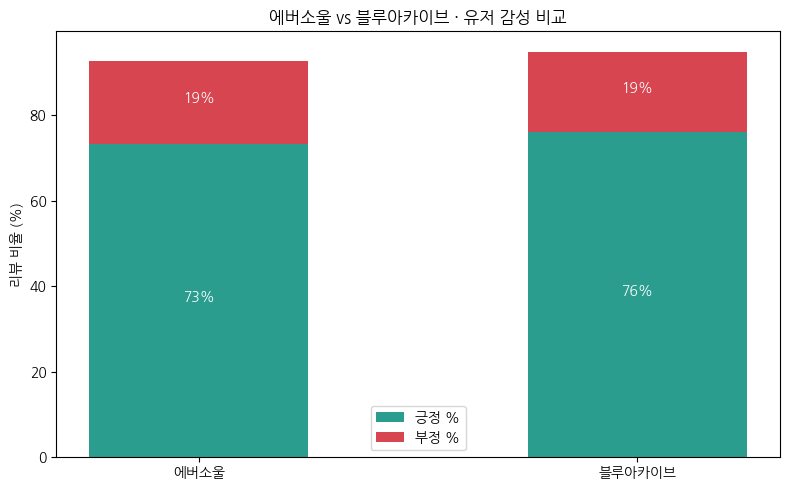

In [17]:
# 두 게임 긍/부정 비율 비교 그래프
import matplotlib.pyplot as plt

def ratio(d):
    v = d["sentiment"].value_counts(normalize=True) * 100
    return v.get("긍정", 0), v.get("부정", 0)

es_pos, es_neg = ratio(df)      # 에버소울
ba_pos_r, ba_neg_r = ratio(ba)  # 블아

labels = ["에버소울", "블루아카이브"]
pos_vals = [es_pos, ba_pos_r]
neg_vals = [es_neg, ba_neg_r]

x = range(len(labels))
plt.figure(figsize=(8, 5))
plt.bar(x, pos_vals, width=0.5, label="긍정 %", color="#2a9d8f")
plt.bar(x, neg_vals, width=0.5, bottom=pos_vals, label="부정 %", color="#d64550")
plt.xticks(list(x), labels)
plt.ylabel("리뷰 비율 (%)")
plt.title("에버소울 vs 블루아카이브 · 유저 감성 비교")
plt.legend()
for i, (p, n) in enumerate(zip(pos_vals, neg_vals)):
    plt.text(i, p/2, f"{p:.0f}%", ha="center", color="white", fontweight="bold")
    plt.text(i, p+n/2, f"{n:.0f}%", ha="center", color="white", fontweight="bold")
plt.savefig("sentiment_compare.png", dpi=150, bbox_inches="tight")
plt.savefig("bluearchive_usp.png", dpi=150, bbox_inches="tight")
plt.tight_layout(); plt.show()

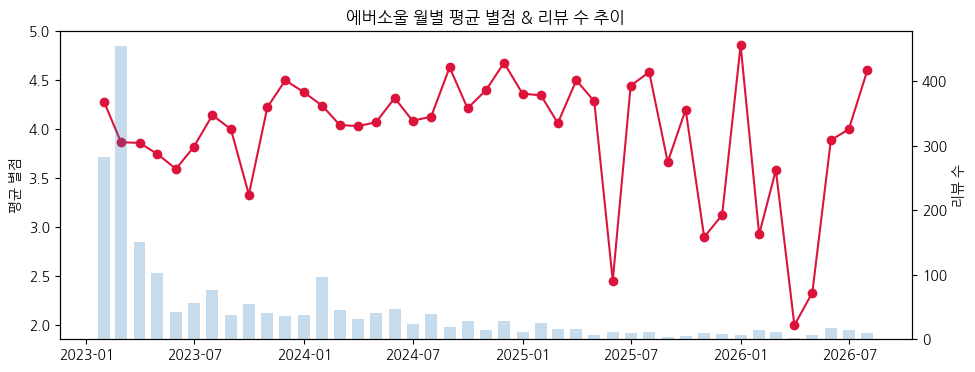

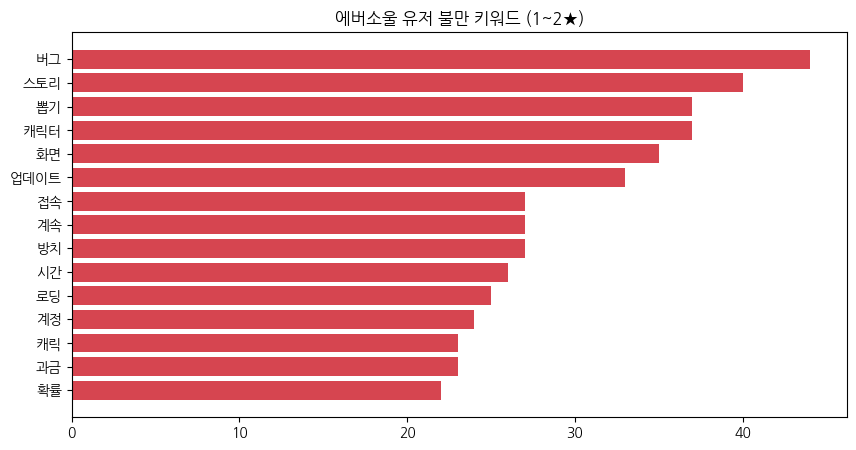

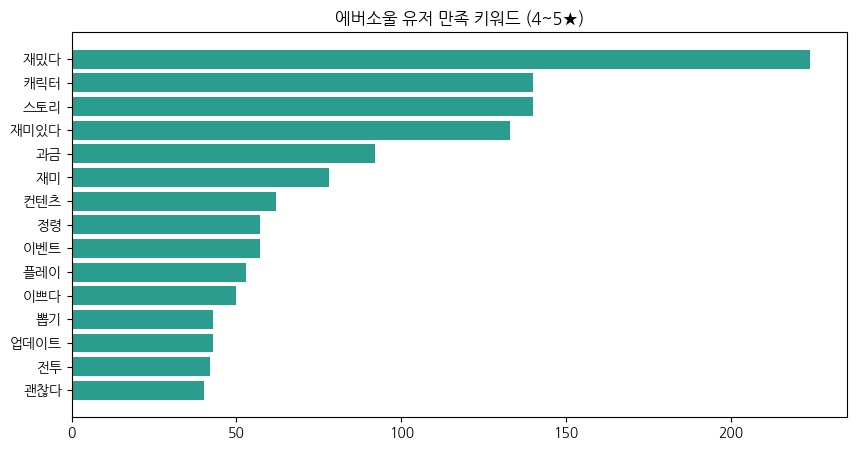

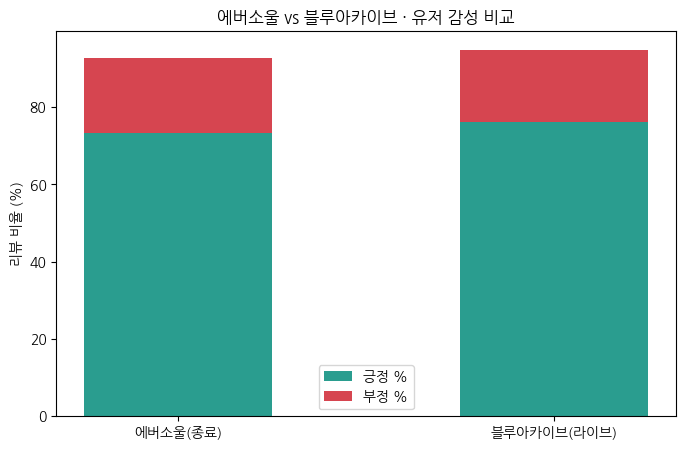

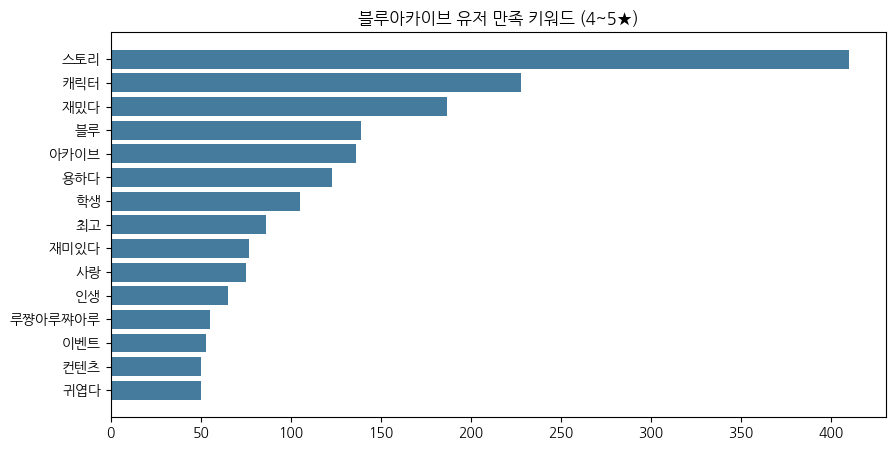

✅ 5개 그래프 저장 완료


In [18]:
# ===== 그래프 5개 한 번에 그리고 저장 =====
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 폰트 설정
path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
fm.fontManager.addfont(path)
plt.rcParams["font.family"] = fm.FontProperties(fname=path).get_name()
plt.rcParams["axes.unicode_minus"] = False

# 1) 에버소울 월별 별점 추이
monthly = df.set_index("date").resample("ME").agg(avg_score=("score","mean"), cnt=("review","count"))
fig, ax1 = plt.subplots(figsize=(11,4))
ax1.plot(monthly.index, monthly["avg_score"], "o-", color="crimson", label="평균 별점")
ax1.set_ylabel("평균 별점")
ax2 = ax1.twinx(); ax2.bar(monthly.index, monthly["cnt"], width=20, alpha=0.25); ax2.set_ylabel("리뷰 수")
plt.title("에버소울 월별 평균 별점 & 리뷰 수 추이")
plt.savefig("eversoul_score_trend.png", dpi=150, bbox_inches="tight"); plt.show()

# 2) 에버소울 Pain Point
pain = extract_keywords(df[df.sentiment=="부정"]["review"]).most_common(15)
plt.figure(figsize=(10,5))
plt.barh([w for w,_ in pain][::-1], [c for _,c in pain][::-1], color="#d64550")
plt.title("에버소울 유저 불만 키워드 (1~2★)")
plt.savefig("eversoul_pain.png", dpi=150, bbox_inches="tight"); plt.show()

# 3) 에버소울 USP
usp = extract_keywords(df[df.sentiment=="긍정"]["review"]).most_common(15)
plt.figure(figsize=(10,5))
plt.barh([w for w,_ in usp][::-1], [c for _,c in usp][::-1], color="#2a9d8f")
plt.title("에버소울 유저 만족 키워드 (4~5★)")
plt.savefig("eversoul_usp.png", dpi=150, bbox_inches="tight"); plt.show()

# 4) 감성 비교
def ratio(d):
    v = d["sentiment"].value_counts(normalize=True)*100
    return v.get("긍정",0), v.get("부정",0)
es = ratio(df); bl = ratio(ba)
plt.figure(figsize=(8,5))
plt.bar([0,1],[es[0],bl[0]], width=0.5, color="#2a9d8f", label="긍정 %")
plt.bar([0,1],[es[1],bl[1]], width=0.5, bottom=[es[0],bl[0]], color="#d64550", label="부정 %")
plt.xticks([0,1],["에버소울(종료)","블루아카이브(라이브)"]); plt.ylabel("리뷰 비율 (%)")
plt.title("에버소울 vs 블루아카이브 · 유저 감성 비교"); plt.legend()
plt.savefig("sentiment_compare.png", dpi=150, bbox_inches="tight"); plt.show()

# 5) 블아 USP
ba_usp = extract_keywords(ba[ba.sentiment=="긍정"]["review"]).most_common(15)
plt.figure(figsize=(10,5))
plt.barh([w for w,_ in ba_usp][::-1], [c for _,c in ba_usp][::-1], color="#457b9d")
plt.title("블루아카이브 유저 만족 키워드 (4~5★)")
plt.savefig("bluearchive_usp.png", dpi=150, bbox_inches="tight"); plt.show()

print("✅ 5개 그래프 저장 완료")

In [19]:
from google.colab import files
for f in ["eversoul_score_trend.png","eversoul_pain.png","eversoul_usp.png","sentiment_compare.png","bluearchive_usp.png"]:
    files.download(f)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>